# TextMamba3D V4.5 — Systematic Evaluation & Ablation

**Target:** Single A100 40GB (Colab)
**Architecture:** V4.4 SeqCA (unchanged) + ET-Enriched Text (V4.5)
**Goal:** Systematic ablation of TTA, ET post-processing, and V4.4+V4.5 ensemble

## Inference Matrix (Phase A: Single Model)

| Run | Model | Text | TTA | Overlap | Save Dir | Est. Time |
|-----|-------|------|-----|---------|----------|-----------|
| A | V4.5 | with | OFF | 0.5 | v45_text_base/ | ~14 min |
| B | V4.5 | no | OFF | 0.5 | v45_notext_base/ | ~14 min |
| C | V4.5 | with | TTA | 0.5 | v45_text_tta/ | ~112 min |
| D | V4.5 | no | TTA | 0.5 | v45_notext_tta/ | ~112 min |

## Ablation Matrix (Phase D: Offline from saved probs)

| Config | Source | PostProcess | Note |
|--------|--------|-------------|------|
| 1. V4.5 Baseline | A/B | OFF | Reproduce existing |
| 2. V4.5 +PP | A/B | ON (best_min_size) | |
| 3. V4.5 +TTA | C/D | OFF | |
| 4. V4.5 +TTA+PP | C/D | ON (best_min_size) | Best single model |
| 5. Ensemble base | E/F | OFF | |
| 6. Ensemble +PP | E/F | ON (best_min_size) | Best overall |

In [1]:
# Cell 1: Mount Drive + Install packages
from google.colab import drive
drive.mount('/content/drive')

# GPU check
!nvidia-smi 2>/dev/null || echo "No GPU detected (CPU mode)"

# Install packages (cached on Drive for speed)
!pip install -q --cache-dir=/content/drive/MyDrive/pip_cache \
    mamba-ssm causal-conv1d transformers nibabel tensorboard \
    pyyaml tqdm scipy matplotlib pandas

Mounted at /content/drive
Wed Mar 18 11:09:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             52W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+---------------------

In [2]:
# Cell 2: Extract code + data (reused from V4.5 training notebook)
import os, zipfile, shutil

REPO_DIR = '/content/TextMamba3D'
DRIVE_BASE = '/content/drive/MyDrive/TextMamba3D'
DRIVE_CODE_ZIP = os.path.join(DRIVE_BASE, 'TextMamba3D_code.zip')
DRIVE_CODE_DIR = os.path.join(DRIVE_BASE, 'TextMamba3D_code')

# Retrieve code: VS Code plugin sync > Drive zip > Drive folder
tm_file = os.path.join(REPO_DIR, 'models/textmamba3d.py')
if os.path.exists(tm_file):
    print(f'Local code available at {REPO_DIR} (VS Code plugin)')
elif os.path.exists(DRIVE_CODE_ZIP):
    print(f'Extracting code from {DRIVE_CODE_ZIP}...')
    os.makedirs(REPO_DIR, exist_ok=True)
    with zipfile.ZipFile(DRIVE_CODE_ZIP, 'r') as zf:
        zf.extractall(REPO_DIR)
    print(f'Extracted to {REPO_DIR}')
elif os.path.exists(DRIVE_CODE_DIR):
    print(f'Copying code from {DRIVE_CODE_DIR}...')
    shutil.copytree(DRIVE_CODE_DIR, REPO_DIR)
    print(f'Copied to {REPO_DIR}')
else:
    raise FileNotFoundError(
        f'Code not found. Please either:'
        + chr(10) + f'  1. Use VS Code Colab plugin to sync local project'
        + chr(10) + f'  2. Upload TextMamba3D_code.zip to {DRIVE_BASE} on Google Drive'
    )

os.chdir(REPO_DIR)
print(f'Working directory: {os.getcwd()}')

# Extract BraTS data from Drive
DATA_ZIP = os.path.join(DRIVE_BASE, "TextBraTS_data.zip")
DATA_DIR = os.path.join(REPO_DIR, "data/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData")

if not os.path.exists(DATA_DIR):
    os.makedirs(os.path.dirname(DATA_DIR), exist_ok=True)
    if os.path.exists(DATA_ZIP):
        print(f"Extracting {DATA_ZIP}...")
        with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
            zf.extractall(os.path.dirname(DATA_DIR))
        if os.path.exists(DATA_DIR):
            print(f"Data extracted. Cases: {len(os.listdir(DATA_DIR))}")
        else:
            print(f"ERROR: Expected path not found after extraction: {DATA_DIR}")
            print("Actual contents:", os.listdir(os.path.dirname(DATA_DIR)))
    else:
        print(f"ERROR: {DATA_ZIP} not found on Drive")
else:
    print(f"Data already exists. Cases: {len(os.listdir(DATA_DIR))}")

# Count samples
if os.path.exists(DATA_DIR):
    cases = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
    print(f"Total BraTS cases: {len(cases)}")

Extracting code from /content/drive/MyDrive/TextMamba3D/TextMamba3D_code.zip...
Extracted to /content/TextMamba3D
Working directory: /content/TextMamba3D
Extracting /content/drive/MyDrive/TextMamba3D/TextBraTS_data.zip...
Data extracted. Cases: 371
Total BraTS cases: 369


In [3]:
# Cell 3: Apply all V4.4/V4.5 code patches
# Merged from V4.5 training notebook cells 4-7:
#   [v4.4-1] Append SeqCA to fusion.py
#   [v4.4-2] Overwrite textmamba3d.py with MultiScaleSeqCA version
#   [v4.5-1] Patch dataset for ET-enriched text
#   [v4.5-2] Create configs/textbrats_v7.yaml

import pathlib, shutil, yaml
NL = chr(10)
REPO_DIR = '/content/TextMamba3D'

# ============================================================
# [v4.4-1] Append Sequential Cross-Attention to fusion.py
# ============================================================
fusion_path = pathlib.Path(REPO_DIR) / 'models' / 'fusion.py'
content = fusion_path.read_text(encoding='utf-8')

if 'SequentialCrossAttention' in content:
    print("[v4.4-1] SeqCA already exists in fusion.py, skipping")
else:
    seqca_code = NL.join([
        "",
        "",
        "# ---------------------------------------------------------------------------",
        "# Sequential Cross-Attention (TextBraTS-inspired, MICCAI 2025)",
        "# ---------------------------------------------------------------------------",
        "",
        "class SequentialCrossAttention(nn.Module):",
        '    """TextBraTS-style Sequential Cross-Attention for text-guided segmentation.',
        "",
        "    Two-step cross-attention that reverses the Q/KV direction:",
        "      Step 1 (T2I): Text=Q, Image=KV -> refined features (text-length)",
        "      Step 2 (I2T): Image=Q, Refined=KV -> joint features (image-length)",
        '    """',
        "",
        "    def __init__(self, feat_dim: int, text_dim: int, num_heads: int = 4):",
        "        super().__init__()",
        '        assert feat_dim % num_heads == 0, \\',
        '            f"feat_dim ({feat_dim}) must be divisible by num_heads ({num_heads})"',
        "        self.num_heads = num_heads",
        "        self.head_dim = feat_dim // num_heads",
        "        self.scale = self.head_dim ** -0.5",
        "",
        "        # Project text to image feature dimension",
        "        self.text_proj = nn.Sequential(",
        "            nn.Linear(text_dim, feat_dim),",
        "            nn.LayerNorm(feat_dim),",
        "        )",
        "",
        "        # Step 1: Text queries Image (T2I)",
        "        self.t2i_norm_q = nn.LayerNorm(feat_dim)",
        "        self.t2i_norm_kv = nn.LayerNorm(feat_dim)",
        "        self.t2i_q = nn.Linear(feat_dim, feat_dim)",
        "        self.t2i_k = nn.Linear(feat_dim, feat_dim)",
        "        self.t2i_v = nn.Linear(feat_dim, feat_dim)",
        "        self.t2i_out = nn.Sequential(",
        "            nn.Linear(feat_dim, feat_dim),",
        "            nn.LayerNorm(feat_dim),",
        "        )",
        "",
        "        # Step 2: Image queries Refined (I2T)",
        "        self.i2t_norm_q = nn.LayerNorm(feat_dim)",
        "        self.i2t_norm_kv = nn.LayerNorm(feat_dim)",
        "        self.i2t_q = nn.Linear(feat_dim, feat_dim)",
        "        self.i2t_k = nn.Linear(feat_dim, feat_dim)",
        "        self.i2t_v = nn.Linear(feat_dim, feat_dim)",
        "        self.i2t_out = nn.Linear(feat_dim, feat_dim)",
        "",
        "        # Zero-init Step 2 output for identity-preserving start",
        "        nn.init.zeros_(self.i2t_out.weight)",
        "        nn.init.zeros_(self.i2t_out.bias)",
        "",
        "    def _multi_head_attn(",
        "        self,",
        "        q: torch.Tensor,",
        "        k: torch.Tensor,",
        "        v: torch.Tensor,",
        "        mask: torch.Tensor | None = None,",
        "    ) -> torch.Tensor:",
        '        """Multi-head attention computation."""',
        "        B, Nq, D = q.shape",
        "        H, hd = self.num_heads, self.head_dim",
        "",
        "        q = q.reshape(B, Nq, H, hd).transpose(1, 2)",
        "        k = k.reshape(B, -1, H, hd).transpose(1, 2)",
        "        v = v.reshape(B, -1, H, hd).transpose(1, 2)",
        "",
        "        attn = (q @ k.transpose(-2, -1)) * self.scale",
        "",
        "        if mask is not None:",
        "            attn = attn.masked_fill(",
        "                mask.unsqueeze(1).unsqueeze(2) == 0,",
        "                float('-inf'),",
        "            )",
        "",
        "        attn = attn.softmax(dim=-1)",
        "        attn = torch.nan_to_num(attn)",
        "",
        "        out = (attn @ v).transpose(1, 2).reshape(B, Nq, D)",
        "        return out",
        "",
        "    def forward(",
        "        self,",
        "        x: torch.Tensor,",
        "        text_feat: torch.Tensor,",
        "        text_mask: torch.Tensor | None = None,",
        "    ) -> torch.Tensor:",
        '        """Forward: x=[B,N,D] image, text_feat=[B,M,D_text] -> [B,N,D]."""',
        "        residual = x",
        "        text_proj = self.text_proj(text_feat)",
        "",
        "        # Step 1: Text=Q, Image=KV",
        "        q1 = self.t2i_q(self.t2i_norm_q(text_proj))",
        "        k1 = self.t2i_k(self.t2i_norm_kv(x))",
        "        v1 = self.t2i_v(self.t2i_norm_kv(x))",
        "        refined = self.t2i_out(self._multi_head_attn(q1, k1, v1))",
        "",
        "        # Step 2: Image=Q, Refined=KV",
        "        q2 = self.i2t_q(self.i2t_norm_q(x))",
        "        k2 = self.i2t_k(self.i2t_norm_kv(refined))",
        "        v2 = self.i2t_v(self.i2t_norm_kv(refined))",
        "        joint = self.i2t_out(self._multi_head_attn(q2, k2, v2, text_mask))",
        "",
        "        return residual + joint",
        "",
        "",
        "class MultiScaleSeqCA(nn.Module):",
        '    """Apply Sequential Cross-Attention at multiple encoder scales."""',
        "",
        "    def __init__(self, stage_dims: list[int], text_dim: int, num_heads: int = 4):",
        "        super().__init__()",
        "        self.attn_layers = nn.ModuleList([",
        "            SequentialCrossAttention(dim, text_dim, num_heads=num_heads)",
        "            for dim in stage_dims",
        "        ])",
        "",
        "    def forward(",
        "        self,",
        "        features: list[torch.Tensor],",
        "        text_feat: torch.Tensor,",
        "        text_mask: torch.Tensor | None = None,",
        "    ) -> list[torch.Tensor]:",
        "        return [",
        "            attn(feat, text_feat, text_mask)",
        "            for attn, feat in zip(self.attn_layers, features)",
        "        ]",
    ])
    fusion_path.write_text(content + NL + seqca_code + NL, encoding='utf-8')
    print("[v4.4-1] Appended SequentialCrossAttention + MultiScaleSeqCA to fusion.py")

# ============================================================
# [v4.4-2] Overwrite textmamba3d.py with V4.4 SeqCA version
# ============================================================
tm_path = pathlib.Path(REPO_DIR) / 'models' / 'textmamba3d.py'

tm_content = NL.join([
    "# models/textmamba3d.py",
    '"""Text-guided 3D medical image segmentation with Mamba architecture."""',
    "",
    "from typing import Optional",
    "",
    "import torch",
    "import torch.nn as nn",
    "",
    "from .decoder_3d import MambaDecoder3D",
    "from .encoder_3d import MambaEncoder3D",
    "from .fusion import MultiScaleSeqCA",
    "from .text_encoder import TextMambaEncoder",
    "",
    "",
    "class TextMamba3D(nn.Module):",
    '    """Text-guided 3D medical image segmentation model using Mamba architecture."""',
    "",
    "    def __init__(",
    "        self,",
    "        img_size: tuple[int, int, int] = (96, 96, 96),",
    "        in_channels: int = 4,",
    "        out_channels: int = 4,",
    "        embed_dim: int = 96,",
    "        depths: list[int] = [2, 2, 2, 2],",
    "        patch_size: tuple[int, int, int] = (4, 4, 4),",
    "        text_embed_dim: int = 256,",
    "        text_max_len: int = 256,",
    "        text_depth: int = 4,",
    "        d_state: int = 16,",
    "        dropout: float = 0.0,",
    "        use_pretrained_text: bool = True,",
    "        unfreeze_text_layers: int = 0,",
    "        use_checkpoint: bool = False,",
    "        text_model_path: str | None = None,",
    "        deep_supervision: bool = False,",
    "    ) -> None:",
    "        super().__init__()",
    "",
    "        self.text_embed_dim = text_embed_dim",
    "        self.text_max_len = text_max_len",
    "        bottleneck_dim = embed_dim * (2 ** (len(depths) - 1))",
    "",
    "        self.img_encoder = MambaEncoder3D(",
    "            img_size=img_size,",
    "            in_channels=in_channels,",
    "            embed_dim=embed_dim,",
    "            depths=depths,",
    "            patch_size=patch_size,",
    "            d_state=d_state,",
    "            dropout=dropout,",
    "            use_checkpoint=use_checkpoint,",
    "        )",
    "",
    "        self.text_encoder = TextMambaEncoder(",
    "            embed_dim=text_embed_dim,",
    "            max_len=text_max_len,",
    "            depth=text_depth,",
    "            d_state=d_state,",
    "            dropout=dropout,",
    "            use_pretrained=use_pretrained_text,",
    "            unfreeze_last_n=unfreeze_text_layers,",
    "            model_path=text_model_path,",
    "        )",
    "",
    "        # Multi-scale cross-attention: text guides skip connections at stages 1,2,3",
    "        stage_dims = [embed_dim * (2 ** i) for i in range(1, len(depths))]",
    "        self.multi_scale_attn = MultiScaleSeqCA(",
    "            stage_dims=stage_dims,",
    "            text_dim=text_embed_dim,",
    "            num_heads=4,",
    "        )",
    "",
    "        self.decoder = MambaDecoder3D(",
    "            img_size=img_size,",
    "            patch_size=patch_size,",
    "            out_channels=out_channels,",
    "            embed_dim=embed_dim,",
    "            depths=depths,",
    "            d_state=d_state,",
    "            dropout=dropout,",
    "            use_checkpoint=use_checkpoint,",
    "            deep_supervision=deep_supervision,",
    "        )",
    "",
    "        self.img_proj = nn.Sequential(",
    "            nn.Linear(bottleneck_dim, text_embed_dim),",
    "            nn.LayerNorm(text_embed_dim),",
    "        )",
    "",
    "    def forward(",
    "        self,",
    "        img: torch.Tensor,",
    "        text_ids: Optional[torch.Tensor] = None,",
    "        attention_mask: Optional[torch.Tensor] = None,",
    "        return_features: bool = False,",
    "        use_text: bool = True,",
    "    ) -> torch.Tensor | tuple[",
    "        torch.Tensor,",
    "        Optional[torch.Tensor],",
    "        Optional[torch.Tensor],",
    "        Optional[torch.Tensor],",
    "    ]:",
    '        """Forward pass for text-guided 3D segmentation."""',
    "        img_features = self.img_encoder(img)",
    "",
    "        has_text = use_text and text_ids is not None",
    "        if has_text:",
    "            text_features = self.text_encoder(text_ids, attention_mask)",
    "            fused = self.multi_scale_attn(",
    "                img_features[1:], text_features, attention_mask",
    "            )",
    "            decoder_features = [img_features[0]] + fused",
    "        else:",
    "            decoder_features = img_features",
    "",
    "        seg_output = self.decoder(decoder_features)",
    "",
    "        if not return_features:",
    "            return seg_output",
    "",
    "        if has_text:",
    "            pixel_feat = decoder_features[-1]",
    "            img_global = self.img_proj(pixel_feat.mean(dim=1))",
    "            text_global = self.text_encoder.get_global_feature(text_features)",
    "            return seg_output, img_global, text_global, pixel_feat",
    "        else:",
    "            return seg_output, None, None, None",
    "",
    "    def forward_without_text(self, img: torch.Tensor) -> torch.Tensor:",
    '        """Convenience method for inference without text guidance."""',
    "        return self.forward(img, text_ids=None, use_text=False)",
    "",
])

tm_path.write_text(tm_content, encoding='utf-8')

# Clear __pycache__
cache_dir = pathlib.Path(REPO_DIR) / 'models' / '__pycache__'
if cache_dir.exists():
    shutil.rmtree(cache_dir)
    print("[v4.4-2] Cleared models/__pycache__")

written = tm_path.read_text(encoding='utf-8')
assert 'MultiScaleSeqCA' in written, "FAIL: MultiScaleSeqCA not found"
assert 'self.multi_scale_attn' in written, "FAIL: self.multi_scale_attn not found"
print(f"[v4.4-2] Wrote textmamba3d.py ({len(written.splitlines())} lines)")

# ============================================================
# [v4.5-1] Patch dataset for ET-enriched text
# ============================================================
ds_path = pathlib.Path(REPO_DIR) / 'data' / 'brats_textbrats_dataset.py'
ds_content = ds_path.read_text(encoding='utf-8')

if 'et_enriched' in ds_content:
    print("[v4.5-1] ET-enriched patch already applied, skipping")
else:
    ds_content = ds_content.replace(
        "        seed: int = 42," + NL + "    ):",
        "        seed: int = 42," + NL +
        "        et_enriched: bool = False," + NL +
        "        enriched_prob: float = 0.5," + NL +
        "    ):"
    )
    ds_content = ds_content.replace(
        "        self.use_text_features = use_text_features" + NL,
        "        self.use_text_features = use_text_features" + NL +
        "        self.et_enriched = et_enriched" + NL +
        "        self.enriched_prob = enriched_prob" + NL
    )
    method = (NL +
        '    def _load_enriched_text(self, case_dir, case_name):' + NL +
        '        path = os.path.join(case_dir, f"{case_name}_et_enriched.txt")' + NL +
        '        if os.path.exists(path):' + NL +
        "            with open(path, 'r', encoding='utf-8') as f:" + NL +
        '                return f.read().strip()' + NL +
        '        return None' + NL + NL
    )
    ds_content = ds_content.replace(
        "    def _load_text_features(",
        method + "    def _load_text_features("
    )
    old_text_load = (
        "        # Load expert text (NO information leakage!)" + NL +
        "        text = self._load_text(case_dir, case_name)"
    )
    new_text_load = (
        "        # Load expert text (NO information leakage!)" + NL +
        "        original_text = self._load_text(case_dir, case_name)" + NL +
        NL +
        "        # LaCLIP stochastic selection" + NL +
        "        if self.et_enriched:" + NL +
        "            enriched = self._load_enriched_text(case_dir, case_name)" + NL +
        "            if self.split == 'train':" + NL +
        "                if enriched and np.random.random() < self.enriched_prob:" + NL +
        "                    text = original_text + ' ' + enriched" + NL +
        "                else:" + NL +
        "                    text = original_text" + NL +
        "            else:" + NL +
        "                text = (original_text + ' ' + enriched) if enriched else original_text" + NL +
        "        else:" + NL +
        "            text = original_text"
    )
    ds_content = ds_content.replace(old_text_load, new_text_load)
    ds_path.write_text(ds_content, encoding='utf-8')
    print("[v4.5-1] Patched brats_textbrats_dataset.py")

# Clear data __pycache__
cache = pathlib.Path(REPO_DIR) / 'data' / '__pycache__'
if cache.exists():
    shutil.rmtree(cache)

# ============================================================
# [v4.5-2] Create configs/textbrats_v7.yaml
# ============================================================
config_v7 = {
    'data': {
        'data_dir': './data/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData',
        'dataset_type': 'textbrats',
        'patch_size': [128, 128, 128],
        'batch_size': 4,
        'num_workers': 4,
        'train_ratio': 0.596,
        'val_ratio': 0.149,
        'et_enriched': True,
        'enriched_prob': 0.5,
    },
    'model': {
        'img_size': [128, 128, 128],
        'in_channels': 4, 'out_channels': 4,
        'embed_dim': 48, 'depths': [2, 2, 2, 2],
        'dropout': 0.1, 'text_embed_dim': 256, 'text_max_len': 192,
        'use_pretrained_text': True, 'unfreeze_text_layers': 2,
        'text_model_path': None,
    },
    'loss': {
        'dice_weight': 1.0, 'ce_weight': 1.0, 'edge_weight': 1.0,
        'contrastive_weight': 0.05, 'temperature': 0.07,
        'class_weights': [0.25, 3.0, 1.0, 4.0],
    },
    'augmentation': {'use_elastic': True, 'use_modality_dropout': True},
    'training': {
        'epochs': 200, 'lr': 0.0001, 'weight_decay': 0.01,
        'warmup_epochs': 10, 'contrastive_warmup_epochs': 30,
        'patience': 40, 'gradient_accumulation': 1,
        'gradient_checkpointing': True, 'deep_supervision': True,
        'ds_weights': [0.2, 0.1, 0.05], 'use_amp': True,
        'no_text_ratio': 0.15, 'gradient_clip_norm': 1.0,
    },
    'eval': {
        'metrics': ['dice', 'hd95'],
        'sliding_window': True, 'sw_overlap': 0.5, 'sw_batch_size': 2,
    },
    'experiment': {
        'name': 'TextMamba3D_A100_v4.5_et_enriched',
        'description': 'V4.5: SeqCA + ET-Enriched Text + LaCLIP stochastic selection (p=0.5)',
    },
}

pathlib.Path(REPO_DIR, 'configs').mkdir(exist_ok=True)
with open(os.path.join(REPO_DIR, 'configs/textbrats_v7.yaml'), 'w') as f:
    f.write('# textbrats_v7.yaml - V4.5 ET-Enriched Text + LaCLIP' + NL)
    yaml.dump(config_v7, f, default_flow_style=False, sort_keys=False)

print("[v4.5-2] Created configs/textbrats_v7.yaml")
print("All V4.4/V4.5 patches applied!")

[v4.4-1] SeqCA already exists in fusion.py, skipping
[v4.4-2] Wrote textmamba3d.py (131 lines)
[v4.5-1] ET-enriched patch already applied, skipping
[v4.5-2] Created configs/textbrats_v7.yaml
All V4.4/V4.5 patches applied!


In [4]:
# Cell 4: Patch verification — model type + checkpoint key check
import sys, os, torch, yaml

REPO_DIR = '/content/TextMamba3D'
os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)

# Verify SeqCA fusion module type
from models.fusion import MultiScaleSeqCA
from models.textmamba3d import TextMamba3D
print(f"MultiScaleSeqCA imported: {MultiScaleSeqCA}")

# Quick model instantiation check
with open('configs/textbrats_v7.yaml', 'r', encoding='utf-8') as f:
    cfg_v45 = yaml.safe_load(f)

model_cfg = cfg_v45['model']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Verify model has multi_scale_attn of correct type
from evaluate_full import load_model

DRIVE_CKPT = '/content/drive/MyDrive/TextMamba3D/checkpoints'
v45_ckpt_path = os.path.join(DRIVE_CKPT, 'best_v4.5.pth')

model_v45 = load_model(cfg_v45, v45_ckpt_path, device)
assert hasattr(model_v45, 'multi_scale_attn'), "FAIL: model missing multi_scale_attn"
assert isinstance(model_v45.multi_scale_attn, MultiScaleSeqCA), (
    f"FAIL: multi_scale_attn type is {type(model_v45.multi_scale_attn)}, expected MultiScaleSeqCA"
)

# Verify checkpoint state_dict keys contain SeqCA-specific keys
ckpt = torch.load(v45_ckpt_path, map_location='cpu', weights_only=False)
state_keys = list(ckpt['model'].keys())
seqca_keys = [k for k in state_keys if 'multi_scale_attn' in k]
assert len(seqca_keys) > 0, "FAIL: no multi_scale_attn keys in checkpoint"
print(f"Checkpoint SeqCA keys: {len(seqca_keys)} (e.g. {seqca_keys[0]})")
print(f"Epoch: {ckpt.get('epoch', '?')}, Best Dice: {ckpt.get('best_dice', '?')}")

del ckpt  # free memory
print("Patch verification PASSED")

MultiScaleSeqCA imported: <class 'models.fusion.MultiScaleSeqCA'>


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded checkpoint: epoch=153, best_dice=0.8811871451990946
Checkpoint SeqCA keys: 90 (e.g. multi_scale_attn.attn_layers.0.text_proj.0.weight)
Epoch: 153, Best Dice: 0.8811871451990946
Patch verification PASSED


## Evaluation Functions

Helper functions for systematic evaluation:
- `eval_single_model` -- sliding window inference with optional TTA, saves softmax probs to Drive
- `eval_ensemble` -- probability averaging of two models
- `offline_postprocess` -- load saved probs, apply ET connected-component filter, compute Dice
- `grid_search_min_size` -- sweep min_size on val set (Dice only, no HD95)
- `build_comparison_table` -- pandas DataFrame for ablation results

In [5]:
# Cell 6: All evaluation helper functions
import os, sys, time
import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm

REPO_DIR = '/content/TextMamba3D'
sys.path.insert(0, REPO_DIR)

# Force reload to pick up updated evaluate_full.py
import importlib
if 'evaluate_full' in sys.modules:
    importlib.reload(sys.modules['evaluate_full'])

from evaluate_full import (
    sliding_window_inference,
    sliding_window_inference_tta,
    postprocess_et,
    load_model,
)
from utils.metrics import dice_score_brats_regions, hausdorff_distance_95_brats_regions


def eval_single_model(
    model,
    dataset,
    tokenizer,
    config,
    tta=False,
    overlap=0.5,
    save_dir=None,
    use_text=True,
):
    """Run sliding window inference on all cases, save softmax probs.

    Args:
        model: loaded TextMamba3D model (eval mode)
        dataset: TextBraTSDataset (no transform, full volume)
        tokenizer: HuggingFace tokenizer
        config: yaml config dict
        tta: enable 8-fold flip TTA
        overlap: sliding window overlap fraction
        save_dir: directory to save .npy probs (None = no save)
        use_text: whether to use text guidance

    Returns:
        list of dicts with per-case dice and hd95
    """
    device = next(model.parameters()).device
    patch_size = tuple(config['data']['patch_size'])
    sw_batch_size = config.get('eval', {}).get('sw_batch_size', 2)
    use_amp = config['training'].get('use_amp', True) and device.type == 'cuda'

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    infer_fn = sliding_window_inference_tta if tta else sliding_window_inference
    mode_str = "TTA" if tta else "base"
    text_str = "with-text" if use_text else "no-text"
    print(f"Evaluating {len(dataset)} cases [{text_str}, {mode_str}, overlap={overlap}]")

    results = []
    t0 = time.time()

    with torch.no_grad():
        for idx in tqdm(range(len(dataset)), desc=f'{text_str}/{mode_str}'):
            sample = dataset[idx]
            case_name = sample['case_name']

            # Resume: skip if probs already saved
            if save_dir:
                npy_path = os.path.join(save_dir, f'{case_name}_probs.npy')
                if os.path.exists(npy_path):
                    print(f"  Skip {case_name} (already saved)")
                    # Still compute dice from saved probs for results
                    probs_np = np.load(npy_path).astype(np.float32)
                    probs_tensor = torch.from_numpy(probs_np).unsqueeze(0)
                    mask = sample['mask']
                    dice = dice_score_brats_regions(probs_tensor, mask.unsqueeze(0))
                    target_np = mask.numpy()
                    pred_np = probs_np.argmax(axis=0)
                    hd95 = hausdorff_distance_95_brats_regions(pred_np, target_np)
                    results.append({'case_name': case_name, 'dice': dice, 'hd95': hd95})
                    continue

            image = sample['image'].unsqueeze(0).to(device)
            mask = sample['mask']
            text_ids = sample['text_ids'].unsqueeze(0).to(device)
            attn_mask = sample['attention_mask'].unsqueeze(0).to(device)

            probs = infer_fn(
                model, image, text_ids, attn_mask,
                patch_size=patch_size,
                overlap=overlap,
                use_text=use_text,
                use_amp=use_amp,
                sw_batch_size=sw_batch_size,
            )

            # Save softmax probs as float16
            if save_dir:
                probs_np = probs.squeeze(0).cpu().numpy().astype(np.float16)  # [C, D, H, W]
                np.save(npy_path, probs_np)

            # Compute metrics
            dice = dice_score_brats_regions(probs.cpu(), mask.unsqueeze(0))
            pred_np = probs.argmax(dim=1).squeeze().cpu().numpy()
            target_np = mask.numpy()
            hd95 = hausdorff_distance_95_brats_regions(pred_np, target_np)

            results.append({'case_name': case_name, 'dice': dice, 'hd95': hd95})

            print(f"  {case_name}: Dice={dice['dice_mean']:.4f} "
                  f"(ET={dice['dice_ET']:.4f}, TC={dice['dice_TC']:.4f}, WT={dice['dice_WT']:.4f})")

    elapsed = time.time() - t0
    print(f"Done in {elapsed/60:.1f} min")
    return results


def eval_ensemble(
    model_a,
    model_b,
    dataset,
    tokenizer,
    config_a,
    config_b,
    overlap=0.5,
    save_dir=None,
    use_text=True,
):
    """Ensemble two models by averaging softmax probabilities.

    Args:
        model_a, model_b: two loaded models
        config_a, config_b: their respective configs
        Other args same as eval_single_model

    Returns:
        list of per-case result dicts
    """
    device = next(model_a.parameters()).device
    patch_size_a = tuple(config_a['data']['patch_size'])
    patch_size_b = tuple(config_b['data']['patch_size'])
    sw_batch_a = config_a.get('eval', {}).get('sw_batch_size', 2)
    sw_batch_b = config_b.get('eval', {}).get('sw_batch_size', 2)
    use_amp = config_a['training'].get('use_amp', True) and device.type == 'cuda'

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    text_str = "with-text" if use_text else "no-text"
    print(f"Ensemble eval: {len(dataset)} cases [{text_str}, overlap={overlap}]")

    results = []
    t0 = time.time()

    with torch.no_grad():
        for idx in tqdm(range(len(dataset)), desc=f'ensemble/{text_str}'):
            sample = dataset[idx]
            case_name = sample['case_name']

            # Resume check
            if save_dir:
                npy_path = os.path.join(save_dir, f'{case_name}_probs.npy')
                if os.path.exists(npy_path):
                    print(f"  Skip {case_name} (already saved)")
                    probs_np = np.load(npy_path).astype(np.float32)
                    probs_tensor = torch.from_numpy(probs_np).unsqueeze(0)
                    mask = sample['mask']
                    dice = dice_score_brats_regions(probs_tensor, mask.unsqueeze(0))
                    pred_np = probs_np.argmax(axis=0)
                    hd95 = hausdorff_distance_95_brats_regions(pred_np, mask.numpy())
                    results.append({'case_name': case_name, 'dice': dice, 'hd95': hd95})
                    continue

            image = sample['image'].unsqueeze(0).to(device)
            mask = sample['mask']
            text_ids = sample['text_ids'].unsqueeze(0).to(device)
            attn_mask = sample['attention_mask'].unsqueeze(0).to(device)

            # Model A inference
            probs_a = sliding_window_inference(
                model_a, image, text_ids, attn_mask,
                patch_size=patch_size_a, overlap=overlap,
                use_text=use_text, use_amp=use_amp,
                sw_batch_size=sw_batch_a,
            )

            # Model B inference
            probs_b = sliding_window_inference(
                model_b, image, text_ids, attn_mask,
                patch_size=patch_size_b, overlap=overlap,
                use_text=use_text, use_amp=use_amp,
                sw_batch_size=sw_batch_b,
            )

            # Average softmax probabilities
            probs = 0.5 * probs_a + 0.5 * probs_b

            # Save ensemble probs
            if save_dir:
                probs_np = probs.squeeze(0).cpu().numpy().astype(np.float16)  # [C, D, H, W]
                np.save(npy_path, probs_np)

            # Metrics
            dice = dice_score_brats_regions(probs.cpu(), mask.unsqueeze(0))
            pred_np = probs.argmax(dim=1).squeeze().cpu().numpy()
            hd95 = hausdorff_distance_95_brats_regions(pred_np, mask.numpy())
            results.append({'case_name': case_name, 'dice': dice, 'hd95': hd95})

            print(f"  {case_name}: Dice={dice['dice_mean']:.4f} "
                  f"(ET={dice['dice_ET']:.4f}, TC={dice['dice_TC']:.4f}, WT={dice['dice_WT']:.4f})")

    elapsed = time.time() - t0
    print(f"Ensemble done in {elapsed/60:.1f} min")
    return results


def offline_postprocess(pred_dir, dataset, min_size=50):
    """Load saved probs, apply ET postprocess, compute Dice.

    Args:
        pred_dir: directory containing *_probs.npy files
        dataset: TextBraTSDataset for GT masks
        min_size: minimum ET component voxel count

    Returns:
        list of per-case dice dicts
    """
    results = []
    for idx in range(len(dataset)):
        sample = dataset[idx]
        case_name = sample['case_name']
        mask = sample['mask']

        npy_path = os.path.join(pred_dir, f'{case_name}_probs.npy')
        if not os.path.exists(npy_path):
            print(f"  WARNING: {npy_path} not found, skipping")
            continue

        probs_np = np.load(npy_path).astype(np.float32)
        pred_argmax = probs_np.argmax(axis=0)

        # Apply ET connected-component filter
        pred_clean = postprocess_et(pred_argmax, et_class=3, min_size=min_size)

        # Rebuild one-hot for dice_score_brats_regions
        num_classes = probs_np.shape[0]
        pred_onehot = torch.zeros(1, num_classes, *pred_clean.shape)
        for c in range(num_classes):
            pred_onehot[0, c] = torch.from_numpy((pred_clean == c).astype(np.float32))

        dice = dice_score_brats_regions(pred_onehot, mask.unsqueeze(0))
        results.append({'case_name': case_name, 'dice': dice})

    return results


def grid_search_min_size(pred_dir, dataset, sizes=None):
    """Grid search ET min_size on val set (Dice only).

    Args:
        pred_dir: directory with val set probs
        dataset: val split dataset
        sizes: list of min_size values to try

    Returns:
        (best_min_size, results_dict)
        results_dict: {size: {'ET': mean, 'TC': mean, 'WT': mean, 'Mean': mean}}
    """
    if sizes is None:
        sizes = [20, 50, 100, 200, 500]

    results_dict = {}
    best_size = sizes[0]
    best_mean = -1.0

    for sz in sizes:
        pp_results = offline_postprocess(pred_dir, dataset, min_size=sz)
        if not pp_results:
            print(f"  min_size={sz}: no results")
            continue

        et_vals = [r['dice']['dice_ET'] for r in pp_results]
        tc_vals = [r['dice']['dice_TC'] for r in pp_results]
        wt_vals = [r['dice']['dice_WT'] for r in pp_results]
        mean_vals = [r['dice']['dice_mean'] for r in pp_results]

        avg_et = np.mean(et_vals)
        avg_tc = np.mean(tc_vals)
        avg_wt = np.mean(wt_vals)
        avg_mean = np.mean(mean_vals)

        results_dict[sz] = {
            'ET': avg_et, 'TC': avg_tc, 'WT': avg_wt, 'Mean': avg_mean,
        }

        print(f"  min_size={sz:>4d}: ET={avg_et:.4f}  TC={avg_tc:.4f}  WT={avg_wt:.4f}  Mean={avg_mean:.4f}")

        if avg_mean > best_mean:
            best_mean = avg_mean
            best_size = sz

    print(f"Best min_size = {best_size} (Mean Dice = {best_mean:.4f})")
    return best_size, results_dict


def build_comparison_table(results_dict):
    """Build pandas DataFrame from results.

    Args:
        results_dict: {config_name: {'ET': float, 'TC': float, 'WT': float, 'Mean': float}}

    Returns:
        DataFrame with configs as rows, metrics as columns, + delta vs baseline
    """
    rows = []
    for name, metrics in results_dict.items():
        rows.append({
            'Config': name,
            'ET Dice': metrics['ET'],
            'TC Dice': metrics['TC'],
            'WT Dice': metrics['WT'],
            'Mean Dice': metrics['Mean'],
        })

    df = pd.DataFrame(rows)

    # Compute delta vs explicit baseline config (robust to missing/reordered configs)
    baseline_name = '1. V4.5 text base'
    baseline_rows = df[df['Config'] == baseline_name]
    if len(baseline_rows) > 0:
        baseline = baseline_rows.iloc[0]
        for col in ['ET Dice', 'TC Dice', 'WT Dice', 'Mean Dice']:
            delta_col = col.replace('Dice', 'Delta')
            df[delta_col] = df[col] - baseline[col]

    df = df.set_index('Config')
    return df


print("All helper functions defined.")

All helper functions defined.


## Phase A: V4.5 Single Model Inference (~4.2h total)

Four runs covering all combinations of text guidance and TTA:
- **Run A**: with-text, no TTA (~14 min)
- **Run B**: no-text, no TTA (~14 min)
- **Run C**: with-text, TTA 8-fold (~112 min)
- **Run D**: no-text, TTA 8-fold (~112 min)

All runs save softmax probs (float16) to Drive for offline post-processing.
Resume-safe: re-running a cell skips already-completed cases.

In [6]:
# Cell 8: Run A — V4.5 with-text, no TTA, overlap=0.5
import os, sys, yaml, torch
from transformers import AutoTokenizer

REPO_DIR = '/content/TextMamba3D'
os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)

from data.brats_textbrats_dataset import TextBraTSDataset
from models.text_encoder import TextMambaEncoder
from evaluate_full import load_model

DRIVE_CKPT = '/content/drive/MyDrive/TextMamba3D/checkpoints'
DRIVE_EVAL = '/content/drive/MyDrive/TextMamba3D/eval_preds'

# Load V4.5 config and model
with open('configs/textbrats_v7.yaml', 'r', encoding='utf-8') as f:
    cfg_v45 = yaml.safe_load(f)

device = torch.device('cuda')
model_v45 = load_model(cfg_v45, os.path.join(DRIVE_CKPT, 'best_v4.5.pth'), device)

# Tokenizer
model_cfg = cfg_v45['model']
text_model_path = model_cfg.get('text_model_path') or TextMambaEncoder.PUBMEDBERT_NAME
tokenizer = AutoTokenizer.from_pretrained(text_model_path)

# Test dataset (full volume, no transform)
data_cfg = cfg_v45['data']
test_dataset = TextBraTSDataset(
    data_dir=data_cfg['data_dir'],
    split='test',
    transform=None,
    tokenizer=tokenizer,
    max_text_len=model_cfg.get('text_max_len', 256),
    train_ratio=data_cfg.get('train_ratio', 0.596),
    val_ratio=data_cfg.get('val_ratio', 0.149),
    et_enriched=data_cfg.get('et_enriched', False),
    enriched_prob=data_cfg.get('enriched_prob', 0.5),
)

# Run A: with-text, no TTA
results_A = eval_single_model(
    model=model_v45,
    dataset=test_dataset,
    tokenizer=tokenizer,
    config=cfg_v45,
    tta=False,
    overlap=0.5,
    save_dir=os.path.join(DRIVE_EVAL, 'v45_text_base'),
    use_text=True,
)
print(f"Run A complete: {len(results_A)} cases")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded checkpoint: epoch=153, best_dice=0.8811871451990946


tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

  Skip BraTS20_Training_349 (already saved)


with-text/base:  99%|█████████▉| 94/95 [15:03<00:09,  9.33s/it]

  Skip BraTS20_Training_103 (already saved)


with-text/base: 100%|██████████| 95/95 [15:14<00:00,  9.62s/it]

Done in 15.2 min
Run A complete: 95 cases


In [7]:
# Cell 9: Run B — V4.5 no-text, no TTA, overlap=0.5
results_B = eval_single_model(
    model=model_v45,
    dataset=test_dataset,
    tokenizer=tokenizer,
    config=cfg_v45,
    tta=False,
    overlap=0.5,
    save_dir=os.path.join(DRIVE_EVAL, 'v45_notext_base'),
    use_text=False,
)
print(f"Run B complete: {len(results_B)} cases")

Evaluating 95 cases [no-text, base, overlap=0.5]


no-text/base:   0%|          | 0/95 [00:00<?, ?it/s]

  Skip BraTS20_Training_328 (already saved)


no-text/base:   1%|          | 1/95 [00:09<15:17,  9.76s/it]

  Skip BraTS20_Training_028 (already saved)


...

  Skip BraTS20_Training_349 (already saved)


no-text/base:  99%|█████████▉| 94/95 [14:56<00:09,  9.56s/it]

  Skip BraTS20_Training_103 (already saved)


no-text/base: 100%|██████████| 95/95 [15:05<00:00,  9.53s/it]

Done in 15.1 min
Run B complete: 95 cases


In [8]:
# Cell 10: Run C — V4.5 with-text, TTA, overlap=0.5 (~112 min)
results_C = eval_single_model(
    model=model_v45,
    dataset=test_dataset,
    tokenizer=tokenizer,
    config=cfg_v45,
    tta=True,
    overlap=0.5,
    save_dir=os.path.join(DRIVE_EVAL, 'v45_text_tta'),
    use_text=True,
)
print(f"Run C complete: {len(results_C)} cases")

Evaluating 95 cases [with-text, TTA, overlap=0.5]


with-text/TTA:   0%|          | 0/95 [00:00<?, ?it/s]

  Skip BraTS20_Training_328 (already saved)


with-text/TTA:   1%|          | 1/95 [00:10<16:34, 10.58s/it]

  Skip BraTS20_Training_028 (already saved)


...

  Skip BraTS20_Training_349 (already saved)


with-text/TTA:  99%|█████████▉| 94/95 [14:42<00:08,  8.99s/it]

  Skip BraTS20_Training_103 (already saved)


with-text/TTA: 100%|██████████| 95/95 [14:51<00:00,  9.39s/it]

Done in 14.9 min
Run C complete: 95 cases


In [9]:
# Cell 11: Run D — V4.5 no-text, TTA, overlap=0.5 (~112 min)
results_D = eval_single_model(
    model=model_v45,
    dataset=test_dataset,
    tokenizer=tokenizer,
    config=cfg_v45,
    tta=True,
    overlap=0.5,
    save_dir=os.path.join(DRIVE_EVAL, 'v45_notext_tta'),
    use_text=False,
)
print(f"Run D complete: {len(results_D)} cases")

Evaluating 95 cases [no-text, TTA, overlap=0.5]


no-text/TTA:   0%|          | 0/95 [00:00<?, ?it/s]

  Skip BraTS20_Training_328 (already saved)


no-text/TTA:   1%|          | 1/95 [00:10<15:56, 10.18s/it]

  Skip BraTS20_Training_028 (already saved)


...

  Skip BraTS20_Training_349 (already saved)


no-text/TTA:  99%|█████████▉| 94/95 [14:48<00:09,  9.55s/it]

  Skip BraTS20_Training_103 (already saved)


no-text/TTA: 100%|██████████| 95/95 [14:58<00:00,  9.46s/it]

Done in 15.0 min
Run D complete: 95 cases


## Phase B: ET Post-Processing Grid Search (val set)

Search `min_size` in {20, 50, 100, 200, 500} on the **val split** (55 cases).
Uses Run A's inference logic on val set to generate val probs, then sweeps offline.
Only computes Dice (no HD95) for speed. Selected `best_min_size` applied in Phase D.

In [10]:
# Cell 13: Grid search min_size on val set
import os, sys, yaml, torch
from transformers import AutoTokenizer

REPO_DIR = '/content/TextMamba3D'
os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)

from data.brats_textbrats_dataset import TextBraTSDataset
from models.text_encoder import TextMambaEncoder
from evaluate_full import load_model

DRIVE_CKPT = '/content/drive/MyDrive/TextMamba3D/checkpoints'
DRIVE_EVAL = '/content/drive/MyDrive/TextMamba3D/eval_preds'

with open('configs/textbrats_v7.yaml', 'r', encoding='utf-8') as f:
    cfg_v45 = yaml.safe_load(f)

model_cfg = cfg_v45['model']
data_cfg = cfg_v45['data']
text_model_path = model_cfg.get('text_model_path') or TextMambaEncoder.PUBMEDBERT_NAME
tokenizer = AutoTokenizer.from_pretrained(text_model_path)

# Val dataset for grid search
val_dataset = TextBraTSDataset(
    data_dir=data_cfg['data_dir'],
    split='val',
    transform=None,
    tokenizer=tokenizer,
    max_text_len=model_cfg.get('text_max_len', 256),
    train_ratio=data_cfg.get('train_ratio', 0.596),
    val_ratio=data_cfg.get('val_ratio', 0.149),
    et_enriched=data_cfg.get('et_enriched', False),
    enriched_prob=data_cfg.get('enriched_prob', 0.5),
)
print(f"Val dataset: {len(val_dataset)} cases")

# Step 1: Run inference on val set (with-text, no TTA) if not already done
val_pred_dir = os.path.join(DRIVE_EVAL, 'v45_text_base_val')
device = torch.device('cuda')
model_v45 = load_model(cfg_v45, os.path.join(DRIVE_CKPT, 'best_v4.5.pth'), device)

val_results = eval_single_model(
    model=model_v45,
    dataset=val_dataset,
    tokenizer=tokenizer,
    config=cfg_v45,
    tta=False,
    overlap=0.5,
    save_dir=val_pred_dir,
    use_text=True,
)

# Step 2: Grid search min_size
print()
print("=" * 60)
print("Grid Search: ET min_size on val set")
print("=" * 60)

best_min_size, gs_results = grid_search_min_size(
    pred_dir=val_pred_dir,
    dataset=val_dataset,
    sizes=[20, 50, 100, 200, 500],
)

print()
print(f">>> best_min_size = {best_min_size}")
print("Save this value for Phase D offline post-processing.")

# Free GPU memory
del model_v45
torch.cuda.empty_cache()

TextBraTS val: 54 samples
Val dataset: 54 cases


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded checkpoint: epoch=153, best_dice=0.8811871451990946
Evaluating 54 cases [with-text, base, overlap=0.5]


with-text/base:   0%|          | 0/54 [00:00<?, ?it/s]

...

  Skip BraTS20_Training_268 (already saved)


with-text/base:  98%|█████████▊| 53/54 [08:31<00:09,  9.21s/it]

  Skip BraTS20_Training_201 (already saved)


with-text/base: 100%|██████████| 54/54 [08:41<00:00,  9.66s/it]


Done in 8.7 min

Grid Search: ET min_size on val set
  min_size=  20: ET=0.8032  TC=0.8300  WT=0.8857  Mean=0.8396
  min_size=  50: ET=0.8127  TC=0.8300  WT=0.8857  Mean=0.8428
  min_size= 100: ET=0.8128  TC=0.8300  WT=0.8857  Mean=0.8428
  min_size= 200: ET=0.8128  TC=0.8300  WT=0.8857  Mean=0.8428
  min_size= 500: ET=0.8139  TC=0.8300  WT=0.8857  Mean=0.8432
Best min_size = 500 (Mean Dice = 0.8432)

>>> best_min_size = 500
Save this value for Phase D offline post-processing.


## Phase C: V4.4 + V4.5 Ensemble

Load both checkpoints and run ensemble inference (softmax probability averaging).
- **Run E**: V4.4 + V4.5, with-text (~28 min)
- **Run F**: V4.4 + V4.5, no-text (~28 min)

V4.4 uses `configs/textbrats_a100.yaml`, V4.5 uses `configs/textbrats_v7.yaml`.

In [11]:
# Cell 15: Run E + F -- V4.4 + V4.5 Ensemble
import os, sys, yaml, torch
from transformers import AutoTokenizer

REPO_DIR = '/content/TextMamba3D'
os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)

from data.brats_textbrats_dataset import TextBraTSDataset
from models.text_encoder import TextMambaEncoder
from evaluate_full import load_model

DRIVE_CKPT = '/content/drive/MyDrive/TextMamba3D/checkpoints'
DRIVE_EVAL = '/content/drive/MyDrive/TextMamba3D/eval_preds'

# Load V4.5 config + model
with open('configs/textbrats_v7.yaml', 'r', encoding='utf-8') as f:
    cfg_v45 = yaml.safe_load(f)

# Load V4.4 config + model
with open('configs/textbrats_a100.yaml', 'r', encoding='utf-8') as f:
    cfg_v44 = yaml.safe_load(f)

device = torch.device('cuda')
model_v45 = load_model(cfg_v45, os.path.join(DRIVE_CKPT, 'best_v4.5.pth'), device)
model_v44 = load_model(cfg_v44, os.path.join(DRIVE_CKPT, 'best_v4.4.pth'), device)

# Tokenizer + dataset for ensemble
# Use et_enriched=False + max_text_len=256 so both models get standard text
# (v4.4 was NOT trained on ET-enriched text; 256 is the max of both configs)
model_cfg = cfg_v45['model']
data_cfg = cfg_v45['data']
text_model_path = model_cfg.get('text_model_path') or TextMambaEncoder.PUBMEDBERT_NAME
tokenizer = AutoTokenizer.from_pretrained(text_model_path)

ensemble_max_text_len = max(
    cfg_v45['model'].get('text_max_len', 256),
    cfg_v44['model'].get('text_max_len', 256),
)
test_dataset = TextBraTSDataset(
    data_dir=data_cfg['data_dir'],
    split='test',
    transform=None,
    tokenizer=tokenizer,
    max_text_len=ensemble_max_text_len,
    train_ratio=data_cfg.get('train_ratio', 0.596),
    val_ratio=data_cfg.get('val_ratio', 0.149),
    et_enriched=False,  # standard text only -- v4.4 was not trained on ET-enriched
    enriched_prob=0.0,
)

# Run E: Ensemble with-text
print("=" * 60)
print("Run E: V4.4 + V4.5 Ensemble, with-text")
print("=" * 60)
results_E = eval_ensemble(
    model_a=model_v44,
    model_b=model_v45,
    dataset=test_dataset,
    tokenizer=tokenizer,
    config_a=cfg_v44,
    config_b=cfg_v45,
    overlap=0.5,
    save_dir=os.path.join(DRIVE_EVAL, 'ensemble_text'),
    use_text=True,
)
print(f"Run E complete: {len(results_E)} cases")

# Run F: Ensemble no-text
print()
print("=" * 60)
print("Run F: V4.4 + V4.5 Ensemble, no-text")
print("=" * 60)
results_F = eval_ensemble(
    model_a=model_v44,
    model_b=model_v45,
    dataset=test_dataset,
    tokenizer=tokenizer,
    config_a=cfg_v44,
    config_b=cfg_v45,
    overlap=0.5,
    save_dir=os.path.join(DRIVE_EVAL, 'ensemble_notext'),
    use_text=False,
)
print(f"Run F complete: {len(results_F)} cases")

# Free memory
del model_v44, model_v45
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded checkpoint: epoch=153, best_dice=0.8811871451990946


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

  BraTS20_Training_271: Dice=0.6346 (ET=0.0847, TC=0.9167, WT=0.9023)


ensemble/no-text:  99%|█████████▉| 94/95 [18:33<00:11, 11.77s/it]

  BraTS20_Training_349: Dice=0.9362 (ET=0.9049, TC=0.9634, WT=0.9402)


ensemble/no-text: 100%|██████████| 95/95 [18:45<00:00, 11.85s/it]

  BraTS20_Training_103: Dice=0.9051 (ET=0.8678, TC=0.9401, WT=0.9076)
Ensemble done in 18.8 min
Run F complete: 95 cases


## Results & Visualization

Offline ablation from saved probs (10 configs):
1. V4.5 single model: 4 text + 4 notext variants (base, +PP, +TTA, +TTA+PP)
2. Ensemble (text only): base + PP
3. HD95 for best single-model (#4 text +TTA+PP) and best ensemble (#10 Ensemble +PP)
4. Delta analysis relative to V4.5 text baseline

In [12]:
# Cell 17: Offline ablation -- apply postprocess to all saved preds
import os, sys, yaml, numpy as np, torch
from transformers import AutoTokenizer

REPO_DIR = '/content/TextMamba3D'
os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)

from data.brats_textbrats_dataset import TextBraTSDataset
from models.text_encoder import TextMambaEncoder
from utils.metrics import dice_score_brats_regions, hausdorff_distance_95_brats_regions
from evaluate_full import postprocess_et

DRIVE_EVAL = '/content/drive/MyDrive/TextMamba3D/eval_preds'

# Load config + tokenizer + test dataset
with open('configs/textbrats_v7.yaml', 'r', encoding='utf-8') as f:
    cfg_v45 = yaml.safe_load(f)

model_cfg = cfg_v45['model']
data_cfg = cfg_v45['data']
text_model_path = model_cfg.get('text_model_path') or TextMambaEncoder.PUBMEDBERT_NAME
tokenizer = AutoTokenizer.from_pretrained(text_model_path)

test_dataset = TextBraTSDataset(
    data_dir=data_cfg['data_dir'],
    split='test',
    transform=None,
    tokenizer=tokenizer,
    max_text_len=model_cfg.get('text_max_len', 256),
    train_ratio=data_cfg.get('train_ratio', 0.596),
    val_ratio=data_cfg.get('val_ratio', 0.149),
    et_enriched=False,  # offline eval uses standard text for GT matching only
    enriched_prob=0.0,
)

# best_min_size from Phase B (set manually if re-running from checkpoint)
# best_min_size = 50  # <-- uncomment and set if needed
print(f"Using best_min_size = {best_min_size}")

# Blueprint configs: 6 named configs x text/notext = 10 actual evaluations
# (ensemble only with-text, since that's the primary comparison)
# HD95 for best single-model (#4 text +TTA+PP) and best ensemble (#10 Ensemble +PP)
configs_to_eval = {
    '1. V4.5 text base':        {'dir': 'v45_text_base',    'pp': False},
    '2. V4.5 text +PP':         {'dir': 'v45_text_base',    'pp': True},
    '3. V4.5 text +TTA':        {'dir': 'v45_text_tta',     'pp': False},
    '4. V4.5 text +TTA+PP':     {'dir': 'v45_text_tta',     'pp': True},
    '5. V4.5 notext base':      {'dir': 'v45_notext_base',  'pp': False},
    '6. V4.5 notext +PP':       {'dir': 'v45_notext_base',  'pp': True},
    '7. V4.5 notext +TTA':      {'dir': 'v45_notext_tta',   'pp': False},
    '8. V4.5 notext +TTA+PP':   {'dir': 'v45_notext_tta',   'pp': True},
    '9. Ensemble text base':     {'dir': 'ensemble_text',    'pp': False},
    '10. Ensemble text +PP':     {'dir': 'ensemble_text',    'pp': True},
}

# Configs that get HD95 (best single-model + best ensemble, both with PP)
HD95_CONFIGS = {'4. V4.5 text +TTA+PP', '10. Ensemble text +PP'}

# Evaluate all configs
all_results = {}
hd95_results = {}

for cfg_name, cfg_spec in configs_to_eval.items():
    pred_dir = os.path.join(DRIVE_EVAL, cfg_spec['dir'])
    use_pp = cfg_spec['pp']

    if use_pp:
        pp_results = offline_postprocess(pred_dir, test_dataset, min_size=best_min_size)
        if not pp_results:
            print(f"  {cfg_name}: no results, skipping")
            continue
        et_mean = np.mean([r['dice']['dice_ET'] for r in pp_results])
        tc_mean = np.mean([r['dice']['dice_TC'] for r in pp_results])
        wt_mean = np.mean([r['dice']['dice_WT'] for r in pp_results])
        mean_dice = np.mean([r['dice']['dice_mean'] for r in pp_results])
    else:
        # Load raw probs -> argmax -> dice (no postprocess)
        dice_list = []
        for idx in range(len(test_dataset)):
            sample = test_dataset[idx]
            case_name = sample['case_name']
            mask = sample['mask']
            npy_path = os.path.join(pred_dir, f'{case_name}_probs.npy')
            if not os.path.exists(npy_path):
                continue
            probs_np = np.load(npy_path).astype(np.float32)
            probs_tensor = torch.from_numpy(probs_np).unsqueeze(0)
            dice = dice_score_brats_regions(probs_tensor, mask.unsqueeze(0))
            dice_list.append(dice)

        if not dice_list:
            print(f"  {cfg_name}: no results, skipping")
            continue
        et_mean = np.mean([d['dice_ET'] for d in dice_list])
        tc_mean = np.mean([d['dice_TC'] for d in dice_list])
        wt_mean = np.mean([d['dice_WT'] for d in dice_list])
        mean_dice = np.mean([d['dice_mean'] for d in dice_list])

    all_results[cfg_name] = {
        'ET': et_mean, 'TC': tc_mean, 'WT': wt_mean, 'Mean': mean_dice,
    }
    print(f"  {cfg_name}: ET={et_mean:.4f}  TC={tc_mean:.4f}  WT={wt_mean:.4f}  Mean={mean_dice:.4f}")

    # HD95 for best single-model and best ensemble configs
    if cfg_name in HD95_CONFIGS:
        hd95_list = []
        for idx in range(len(test_dataset)):
            sample = test_dataset[idx]
            case_name = sample['case_name']
            mask = sample['mask']
            npy_path = os.path.join(pred_dir, f'{case_name}_probs.npy')
            if not os.path.exists(npy_path):
                continue
            probs_np = np.load(npy_path).astype(np.float32)
            pred_argmax = probs_np.argmax(axis=0)
            if use_pp:
                pred_argmax = postprocess_et(pred_argmax, et_class=3, min_size=best_min_size)
            hd95 = hausdorff_distance_95_brats_regions(pred_argmax, mask.numpy())
            hd95_list.append(hd95)

        if hd95_list:
            for region in ['hd95_ET', 'hd95_TC', 'hd95_WT']:
                vals = [h[region] for h in hd95_list if not np.isnan(h[region])]
                if vals:
                    hd95_results.setdefault(cfg_name, {})[region] = np.mean(vals)
            print(f"    HD95: {hd95_results.get(cfg_name, {})}")

print()
print("Offline ablation complete.")

TextBraTS test: 95 samples
Using best_min_size = 500
  1. V4.5 text base: ET=0.7612  TC=0.8394  WT=0.8927  Mean=0.8311
  2. V4.5 text +PP: ET=0.7728  TC=0.8394  WT=0.8927  Mean=0.8350
  3. V4.5 text +TTA: ET=0.7842  TC=0.8528  WT=0.9034  Mean=0.8468
  4. V4.5 text +TTA+PP: ET=0.7829  TC=0.8528  WT=0.9034  Mean=0.8464
    HD95: {'hd95_ET': np.float64(3.4266914937236495), 'hd95_TC': np.float64(3.6895505563901723), 'hd95_WT': np.float64(1.4500827289139948)}
  5. V4.5 notext base: ET=0.7604  TC=0.8341  WT=0.8877  Mean=0.8274
  6. V4.5 notext +PP: ET=0.7705  TC=0.8341  WT=0.8877  Mean=0.8308
  7. V4.5 notext +TTA: ET=0.7824  TC=0.8485  WT=0.8990  Mean=0.8433
  8. V4.5 notext +TTA+PP: ET=0.7686  TC=0.8485  WT=0.8990  Mean=0.8387
  9. Ensemble text base: ET=0.7785  TC=0.8497  WT=0.8953  Mean=0.8412
  10. Ensemble text +PP: ET=0.7814  TC=0.8497  WT=0.8953  Mean=0.8422
    HD95: {'hd95_ET': np.float64(3.170273541394322), 'hd95_TC': np.float64(3.654380008298261), 'hd95_WT': np.float64(3.07686456

In [13]:
# Cell 18: Build comparison table + delta analysis
import pandas as pd
import numpy as np

df = build_comparison_table(all_results)

# Format for display
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print("=" * 80)
print("TextMamba3D V4.5 Evaluation — Full Ablation Results (test set)")
print("=" * 80)
print()
print(df.to_string())
print()

# HD95 summary for best configs
if hd95_results:
    print("HD95 (selected configs):")
    for cfg_name, hd in hd95_results.items():
        parts = []
        for k, v in hd.items():
            parts.append(f"{k}={v:.2f}")
        print(f"  {cfg_name}: {', '.join(parts)}")
    print()

# Key findings
if len(all_results) >= 4:
    baseline = all_results.get('1. V4.5 text base', list(all_results.values())[0])
    best_config = max(all_results.items(), key=lambda x: x[1]['Mean'])
    print(f"Baseline (V4.5 text base): Mean Dice = {baseline['Mean']:.4f}")
    print(f"Best config: {best_config[0]} = {best_config[1]['Mean']:.4f}")
    delta = best_config[1]['Mean'] - baseline['Mean']
    print(f"Improvement: +{delta:.4f} ({delta*100:.2f}%)")

TextMamba3D V4.5 Evaluation — Full Ablation Results (test set)

                        ET Dice  TC Dice  WT Dice  Mean Dice  ET Delta  TC Delta  WT Delta  Mean Delta
Config                                                                                                
1. V4.5 text base        0.7612   0.8394   0.8927     0.8311    0.0000    0.0000    0.0000      0.0000
2. V4.5 text +PP         0.7728   0.8394   0.8927     0.8350    0.0116    0.0000    0.0000      0.0039
3. V4.5 text +TTA        0.7842   0.8528   0.9034     0.8468    0.0230    0.0134    0.0107      0.0157
4. V4.5 text +TTA+PP     0.7829   0.8528   0.9034     0.8464    0.0217    0.0134    0.0107      0.0153
5. V4.5 notext base      0.7604   0.8341   0.8877     0.8274   -0.0008   -0.0053   -0.0049     -0.0037
6. V4.5 notext +PP       0.7705   0.8341   0.8877     0.8308    0.0093   -0.0053   -0.0049     -0.0003
7. V4.5 notext +TTA      0.7824   0.8485   0.8990     0.8433    0.0212    0.0091    0.0064      0.0122
8. V4.5 n

Saved: /content/drive/MyDrive/TextMamba3D/eval_preds/v4.5_eval_ablation.png


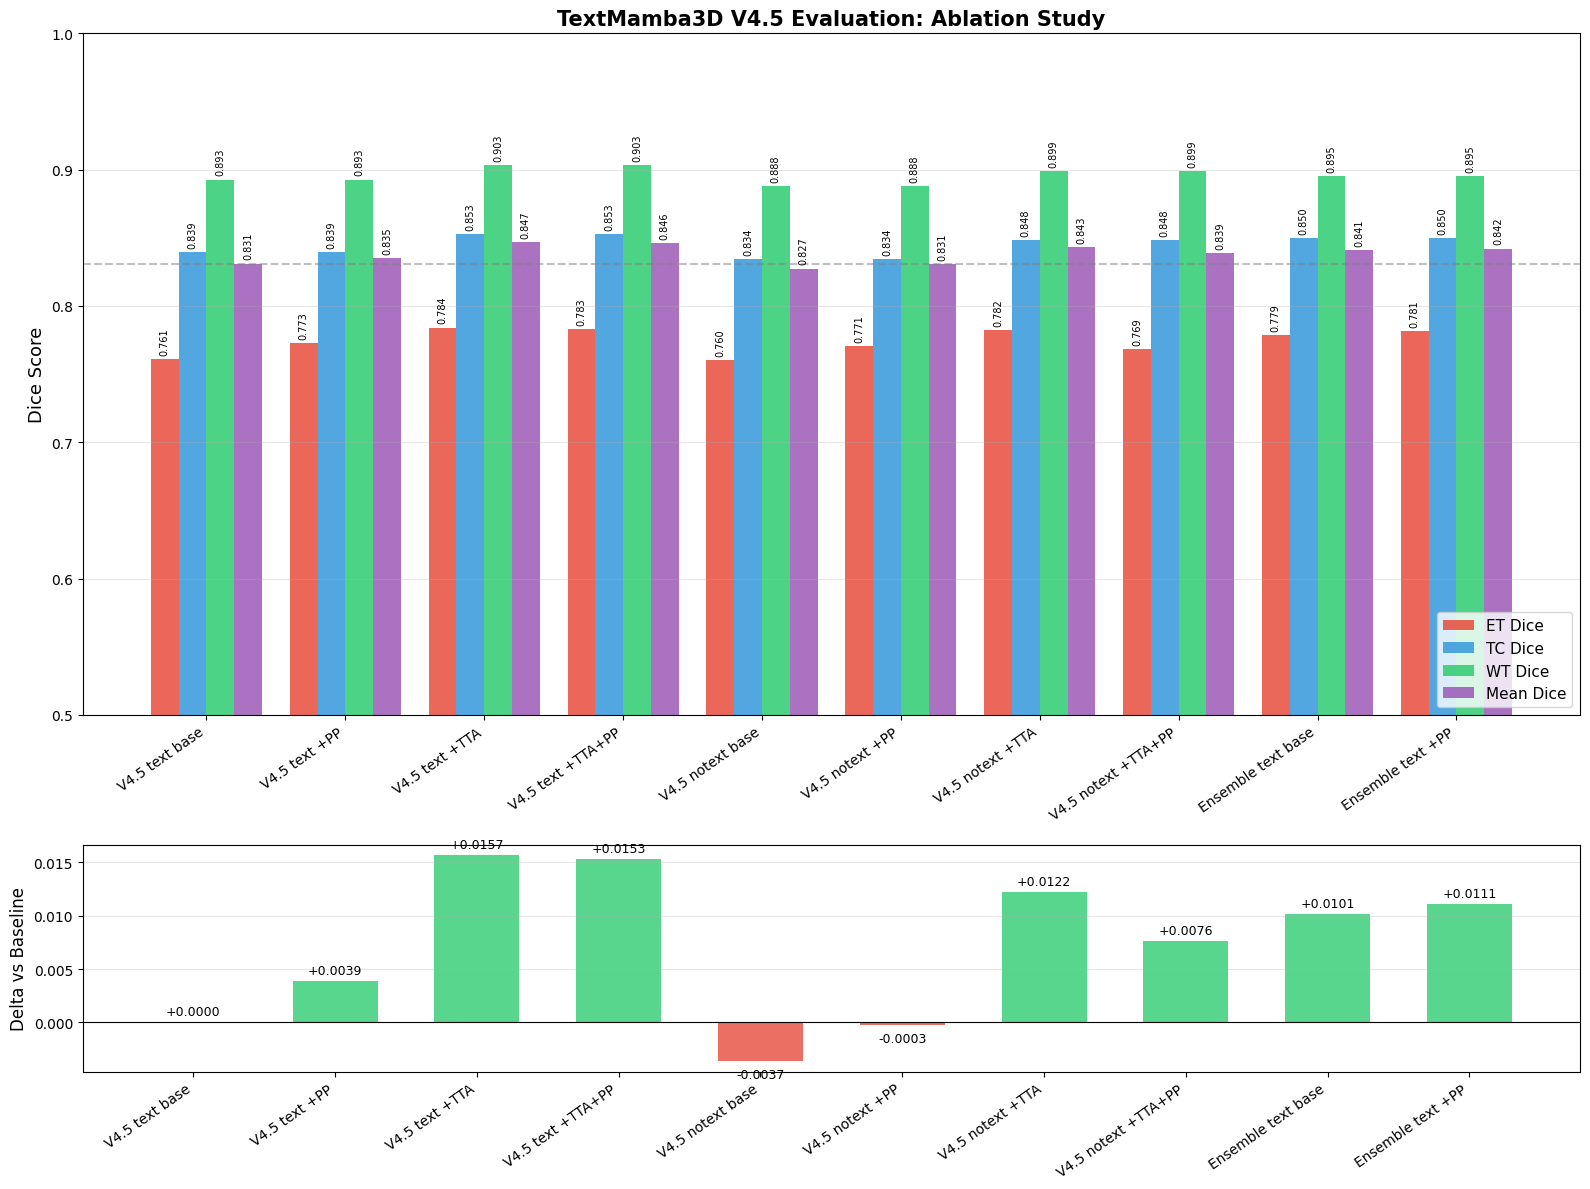

In [14]:
# Cell 19: Visualization — grouped bar chart + delta line
import matplotlib.pyplot as plt
import numpy as np
import os

DRIVE_EVAL = '/content/drive/MyDrive/TextMamba3D/eval_preds'

# Prepare data from all_results
config_names = list(all_results.keys())
# Shorten names for plot labels
short_names = []
for name in config_names:
    # Remove numbering prefix "1. ", "2. " etc.
    short = name.split('. ', 1)[-1] if '. ' in name else name
    short_names.append(short)

et_vals = [all_results[n]['ET'] for n in config_names]
tc_vals = [all_results[n]['TC'] for n in config_names]
wt_vals = [all_results[n]['WT'] for n in config_names]
mean_vals = [all_results[n]['Mean'] for n in config_names]

x = np.arange(len(config_names))
width = 0.2

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [3, 1]})

# Top: Grouped bar chart
bars_et = ax1.bar(x - 1.5*width, et_vals, width, label='ET Dice', color='#e74c3c', alpha=0.85)
bars_tc = ax1.bar(x - 0.5*width, tc_vals, width, label='TC Dice', color='#3498db', alpha=0.85)
bars_wt = ax1.bar(x + 0.5*width, wt_vals, width, label='WT Dice', color='#2ecc71', alpha=0.85)
bars_mean = ax1.bar(x + 1.5*width, mean_vals, width, label='Mean Dice', color='#9b59b6', alpha=0.85)

ax1.set_ylabel('Dice Score', fontsize=13)
ax1.set_title('TextMamba3D V4.5 Evaluation: Ablation Study', fontsize=15, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(short_names, rotation=35, ha='right', fontsize=10)
ax1.legend(loc='lower right', fontsize=11)
ax1.set_ylim(0.5, 1.0)
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=mean_vals[0], color='gray', linestyle='--', alpha=0.5, label='Baseline Mean')

# Add value labels on bars
for bars in [bars_et, bars_tc, bars_wt, bars_mean]:
    for bar in bars:
        h = bar.get_height()
        ax1.annotate(f'{h:.3f}',
                     xy=(bar.get_x() + bar.get_width() / 2, h),
                     xytext=(0, 3), textcoords='offset points',
                     ha='center', va='bottom', fontsize=7, rotation=90)

# Bottom: Delta line (vs baseline)
baseline_mean = mean_vals[0]
deltas = [m - baseline_mean for m in mean_vals]
colors = ['#2ecc71' if d >= 0 else '#e74c3c' for d in deltas]

ax2.bar(x, deltas, 0.6, color=colors, alpha=0.8)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_ylabel('Delta vs Baseline', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(short_names, rotation=35, ha='right', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Add delta value labels
for i, d in enumerate(deltas):
    label = f'+{d:.4f}' if d >= 0 else f'{d:.4f}'
    ax2.annotate(label,
                 xy=(i, d),
                 xytext=(0, 5 if d >= 0 else -12),
                 textcoords='offset points',
                 ha='center', fontsize=9)

plt.tight_layout()

# Save to Drive
save_path = os.path.join(DRIVE_EVAL, 'v4.5_eval_ablation.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved: {save_path}")
plt.show()